In [57]:
%%HTML
<style>
body {
    --vscode-font-family : 'Nasalization';
}

.dataframe {
    font-family : 'Futura';
    # font-family : 'Century Gothic';
    border : 2px solid #252422;
    border-radius : 5px;
    overflow : hidden;
}

.dataframe tr th {
    text-align : center;
}

.dataframe td {
    paddign : 10px;
    text-align : left;
}

.dataframe tr:hover{
    background-color : #ef233c;
}

</style>

# 🛳️ Importation

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder, LabelBinarizer, MinMaxScaler, RobustScaler, StandardScaler, Binarizer
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import make_pipeline, make_union
from sklearn.compose import make_column_transformer, make_column_selector
from sklearn.impute import SimpleImputer

# 🎯 Main

Le fait d'utiliser des pipelines permet de regrouper le code

### 📍 Code sans pipeline

In [59]:
# Données
iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=0)

# Transformer
scaler = StandardScaler()
X_train_transformed = scaler.fit_transform(X_train)

# Estimator
model = SGDClassifier()
model.fit(X_train_transformed, y_train)

# Predict
X_test_transformed = scaler.transform(X_test)
y_pred = model.predict(X_test_transformed)

y_pred

array([2, 1, 0, 2, 0, 2, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 2, 1,
       0, 0, 2, 0, 0, 1, 1, 0, 2, 1, 0, 2, 2, 1, 0, 1, 1, 1, 2, 0, 2, 0,
       0])

### 📍 Code avec pipeline

On obtient le même résultat, avec un code beaucoup plus `simple` et `compréhensible`

In [60]:
model = make_pipeline(StandardScaler(), SGDClassifier())
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred

array([2, 1, 0, 2, 0, 2, 0, 1, 1, 1, 2, 1, 1, 1, 1, 0, 1, 1, 0, 0, 2, 1,
       0, 0, 2, 0, 0, 1, 1, 0, 2, 2, 0, 2, 2, 1, 0, 2, 1, 1, 2, 0, 2, 0,
       0])

# ⛵️ Application sur le cas du Titanic

In [61]:
titanic = sns.load_dataset('titanic')
titanic.head(5)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [62]:
X = titanic.iloc[:, 1:]
y = titanic.iloc[:, 0]

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=0)

## 📍 Transformers

Permet d'effectuer des transformation uniquement sur les colonnes voulues

In [63]:
transformer = make_column_transformer((StandardScaler(), ['age', 'fare']))
transformer.fit_transform(X)

array([[-0.53037664, -0.50244517],
       [ 0.57183099,  0.78684529],
       [-0.25482473, -0.48885426],
       ...,
       [        nan, -0.17626324],
       [-0.25482473, -0.04438104],
       [ 0.15850313, -0.49237783]], shape=(891, 2))

In [64]:
model = make_pipeline(transformer, SGDClassifier())

### 💎 Bonne pratique
> Séparer les tranformation `numériques` et `catégories` <br>
> Cette série de transformation se fait aussi grâce à des `pipelines`

In [65]:
# Choix explicite
numerical_features = ['pclass', 'age', 'fare']
categorical_features = ['sex', 'deck', 'alone']

# Choix dynamique (recommandé car lorsqu'il y a des centaines des colonnes)
numerical_features = make_column_selector(dtype_include=np.number)
categorical_features = make_column_selector(dtype_exclude=np.number)

In [66]:
numerical_pipeline = make_pipeline(SimpleImputer(), StandardScaler())
categorical_pipeline = make_pipeline(SimpleImputer(strategy='most_frequent'), OneHotEncoder())

In [67]:
preprocessor = make_column_transformer(
    (numerical_pipeline, numerical_features),
    (categorical_pipeline,  categorical_features)
)

In [68]:
model = make_pipeline(preprocessor, SGDClassifier())
model.fit(X_train, y_train)

,steps,"[('columntransformer', ...), ('sgdclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('pipeline-1', ...), ('pipeline-2', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [69]:
y_pred = model.predict(X_test)
y_pred

array([0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1,
       0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0])

In [70]:
model.score(X_test, y_test)

1.0

In [71]:
titanic['survived'].unique()

array([0, 1])

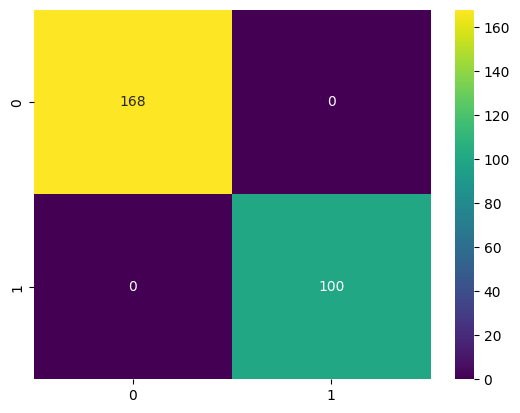

In [72]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap='viridis', fmt='g')
plt.show()

## 📍 Parallel pipeline

Pipeline parrallèle, les résultats seront concaténées en sortie

On voit que les deux première colonnes sont standardisées et les deux dernières binaire

In [73]:
numerical_features = X[['age', 'fare']]

imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
numerical_features = imputer.fit_transform(numerical_features)

pipeline = make_union(StandardScaler(), Binarizer())
pipeline.fit_transform(numerical_features)


array([[-0.5924806 , -0.50244517,  1.        ,  1.        ],
       [ 0.63878901,  0.78684529,  1.        ,  1.        ],
       [-0.2846632 , -0.48885426,  1.        ,  1.        ],
       ...,
       [ 0.        , -0.17626324,  1.        ,  1.        ],
       [-0.2846632 , -0.04438104,  1.        ,  1.        ],
       [ 0.17706291, -0.49237783,  1.        ,  1.        ]],
      shape=(891, 4))